# Preparing the tools

In [33]:
# General-purpose libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

# Model Building
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Model Evaluation
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV, cross_val_score

# Model Saving
import pickle

# Load the dataset

In [34]:
data = pd.read_csv("practic/medical_insurance.csv")
data.shape

(2772, 7)

## Data Exploratory Analysis (EDA)

In [35]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [36]:
data.sample(5)

,age,sex,bmi,children,smoker,region,charges
1296,18,male,26.125,0,no,northeast,1708.92575
2339,44,male,30.200,2,yes,southwest,38998.54600
1809,25,male,30.590,0,no,northeast,2727.39510
498,44,female,23.980,2,no,southeast,8211.10020
1,18,male,33.770,1,no,southeast,1725.55230


In [37]:
data.tail()

,age,sex,bmi,children,smoker,region,charges
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229
2771,54,male,31.600,0,no,southwest,9850.43200


In [38]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   str    
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   str    
 5   region    2772 non-null   str    
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 151.7 KB


In [39]:
data.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [40]:
data["region"].value_counts().sort_values()

region
northeast    658
northwest    664
southwest    684
southeast    766
Name: count, dtype: int64

In [41]:
data["children"].value_counts().sort_values()

children
5      42
4      52
3     324
2     496
1     672
0    1186
Name: count, dtype: int64

## Converting Categorical Features to Numerical

In [42]:
# Create mappings to convert categorical text values into numeric values
clean_data = {
    "sex": {"male": 0, "female": 1},
    "smoker": {"no": 0, "yes": 1},
    "region": {"northwest": 0, "northeast": 1, "southeast": 2, "southwest": 3}
}

# Make a copy of the original dataset to preserve the raw data
data_copy = data.copy()

# Replace categorical values with their corresponding numeric codes
data_copy.replace(clean_data, inplace=True)

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,0,33.770,1,0,2,1725.55230
2,28,0,33.000,3,0,2,4449.46200
3,33,0,22.705,0,0,0,21984.47061
4,32,0,28.880,0,0,0,3866.85520
...,...,...,...,...,...,...,...
2767,47,1,45.320,1,0,2,8569.86180
2768,21,1,34.600,0,0,3,2020.17700
2769,19,0,26.030,1,1,0,16450.89470
2770,23,0,18.715,0,0,0,21595.38229


In [43]:
data_copy.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


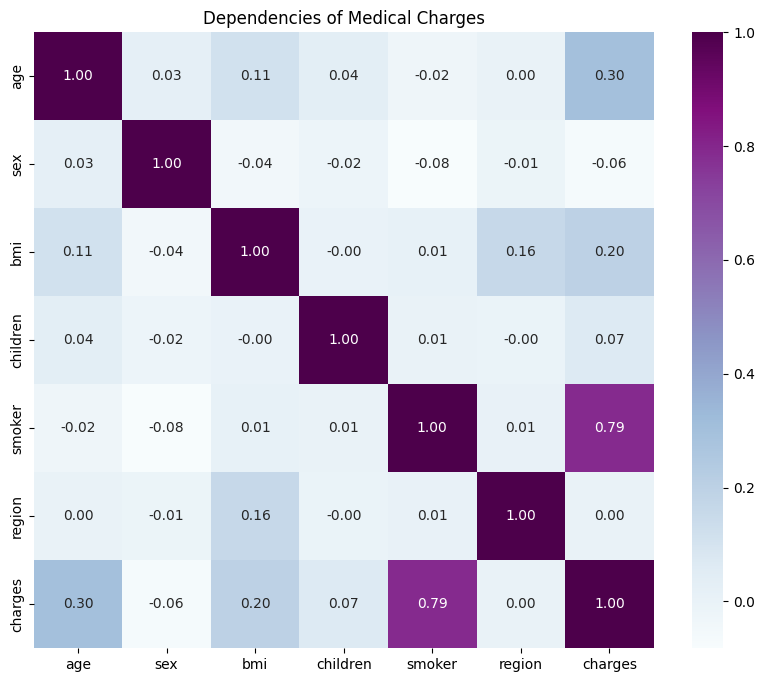

In [44]:
# Correlation Matrix
corr = data_copy.corr()
fig, ax = plt.subplots(figsize = (10, 8))
ax = sns.heatmap(
    corr,
    annot = True,
    fmt = ".2f",
    cmap = "BuPu"
)
plt.title("Dependencies of Medical Charges")
plt.savefig("./SampleImages/corr")

### Smoker, Age and BMI are the most important factor that determines - Charges

Also we see that sex, Children and region do not affect the charges. We might drop this 3 columns as they have less correlation

In [45]:
print(data['sex'].value_counts().sort_values())
print(data['smoker'].value_counts().sort_values())
print(data['region'].value_counts().sort_values())

sex
female    1366
male      1406
Name: count, dtype: int64
smoker
yes     564
no     2208
Name: count, dtype: int64
region
northeast    658
northwest    664
southwest    684
southeast    766
Name: count, dtype: int64


### Now we are confirmed that there are no other values in above pre-processed column, We can proceed with EDA

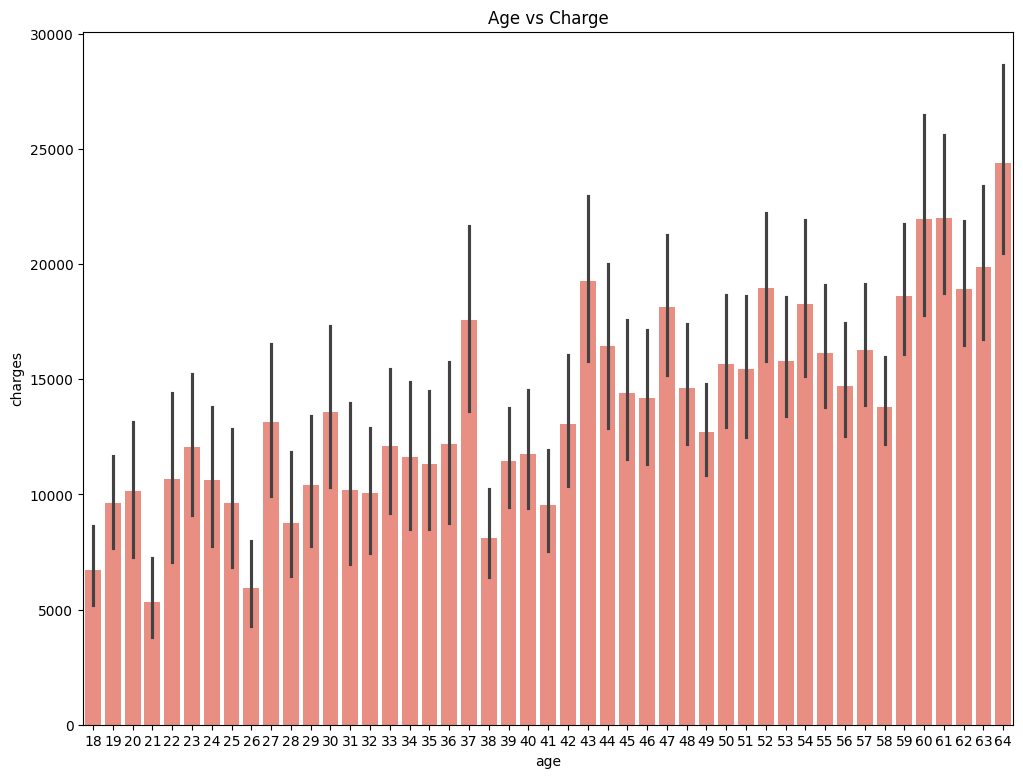

In [46]:
plt.figure(figsize=(12,9))
plt.title('Age vs Charge')
sns.barplot(x='age', y='charges', data=data_copy, color= "salmon")
plt.savefig("./SampleImages/AgeVsCharges")

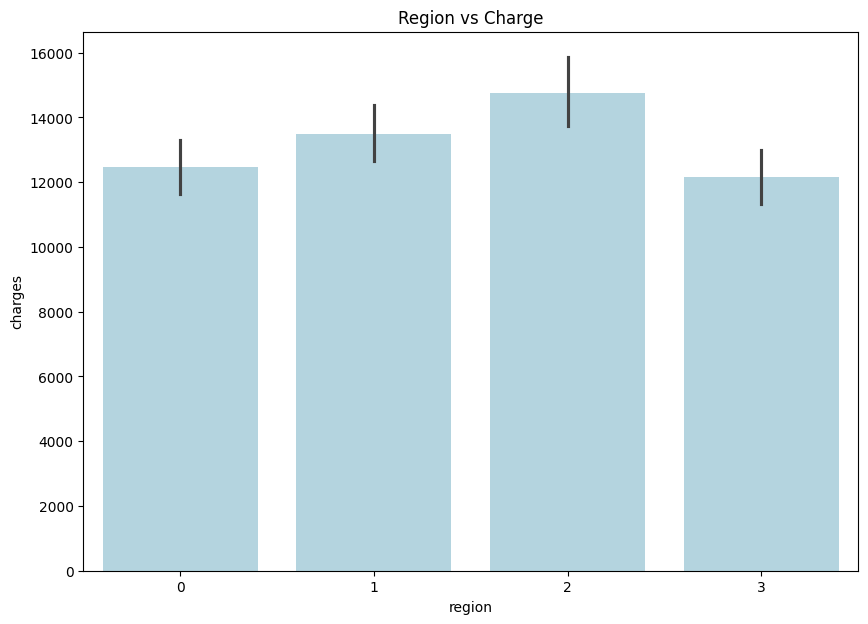

In [47]:
plt.figure(figsize = (10, 7))
plt.title("Region vs Charge")
sns.barplot(data_copy, x = "region", y = "charges", color = "lightblue");

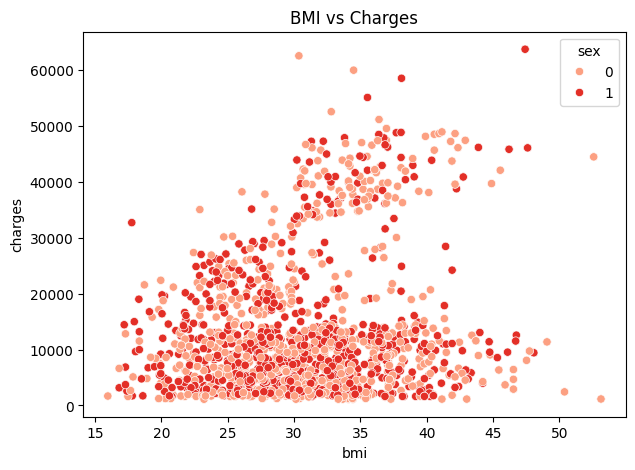

In [48]:
plt.figure(figsize = (7, 5))
plt.title("BMI vs Charges")
sns.scatterplot(data_copy, x = "bmi", y = "charges", hue = "sex", palette = "Reds");

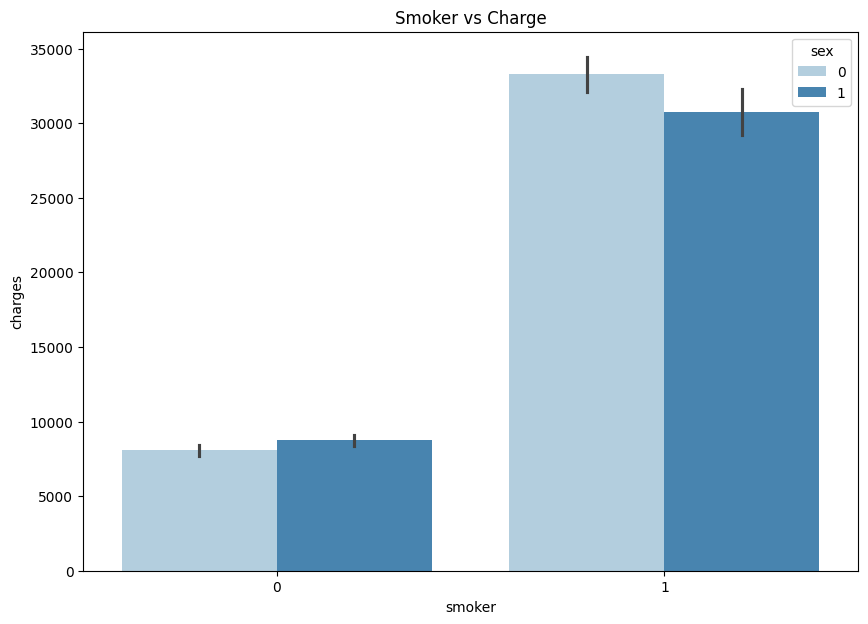

In [49]:
plt.figure(figsize = (10, 7))
plt.title("Smoker vs Charge")
sns.barplot(data_copy, x = "smoker", y = "charges", hue = "sex", palette = "Blues");

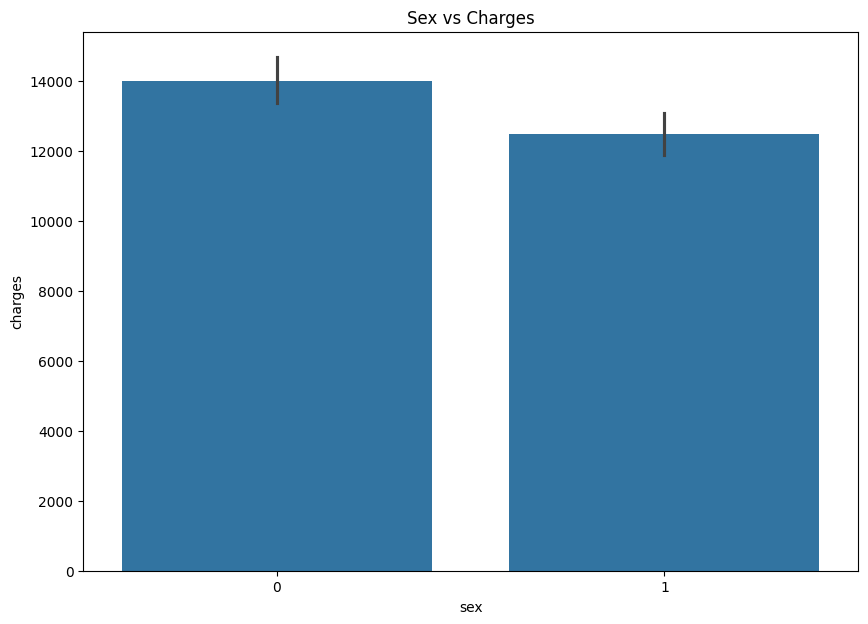

In [50]:
plt.figure(figsize = (10, 7))
plt.title("Sex vs Charges")
sns.barplot(data_copy, x = "sex", y = "charges");

## Plotting Skew and Kurtosis

In [51]:
print("Plotting Skewness vs Kurtosis for all columns\n")

for col in list(data_copy.columns):
    print("{0} : Skewness {1:.3f} and Kurtosis {2:.3f}".format(col, data_copy[col].skew(), data_copy[col].kurt()))

Plotting Skewness vs Kurtosis for all columns

age : Skewness 0.062 and Kurtosis -1.253
sex : Skewness 0.029 and Kurtosis -2.001
bmi : Skewness 0.280 and Kurtosis -0.090
children : Skewness 0.955 and Kurtosis 0.259
smoker : Skewness 1.474 and Kurtosis 0.173
region : Skewness -0.061 and Kurtosis -1.327
charges : Skewness 1.511 and Kurtosis 1.566


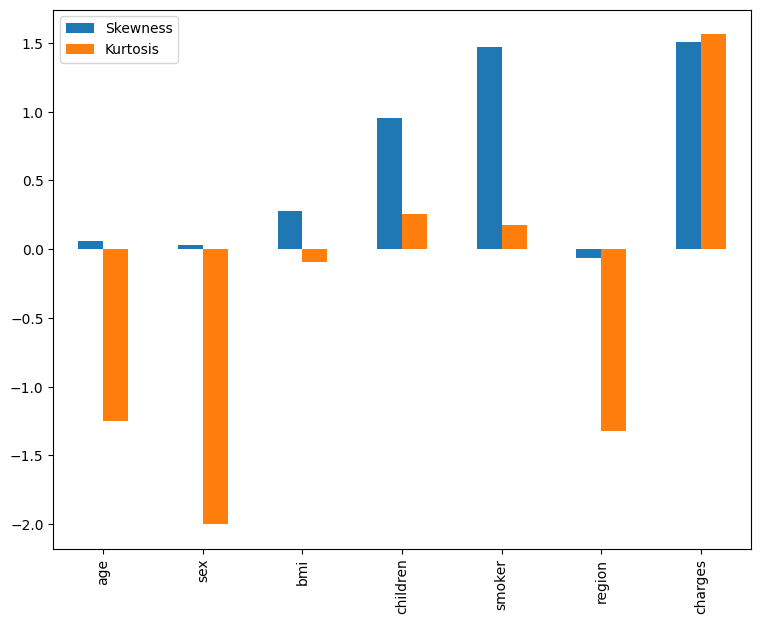

In [52]:
states = pd.DataFrame({
    "Skewness": data_copy.skew(),
    "Kurtosis": data_copy.kurtosis()
})
states.plot(kind = "bar", figsize = (9, 7));

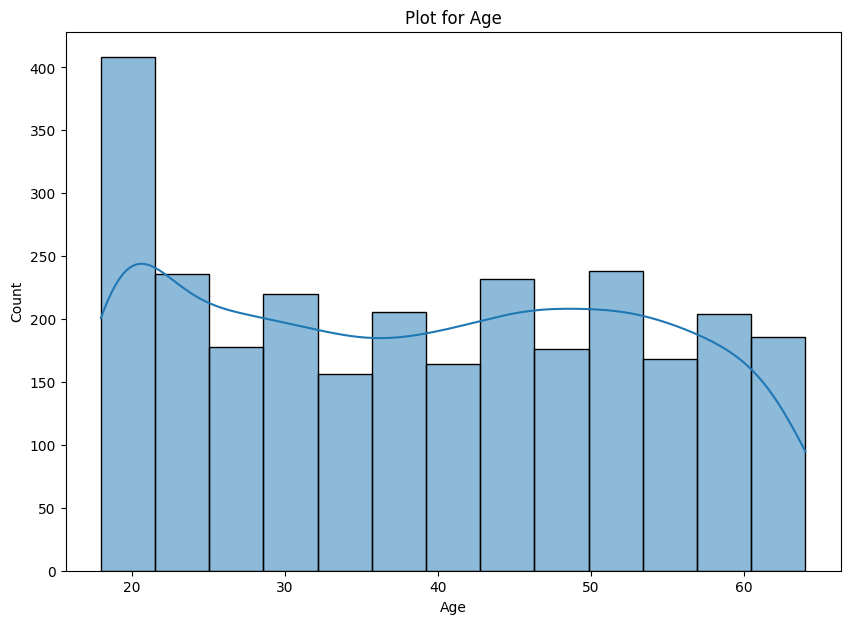

In [53]:
plt.figure(figsize = (10, 7))
sns.histplot(data_copy["age"], kde = True)
plt.title("Plot for Age")
plt.xlabel("Age")
plt.ylabel("Count");

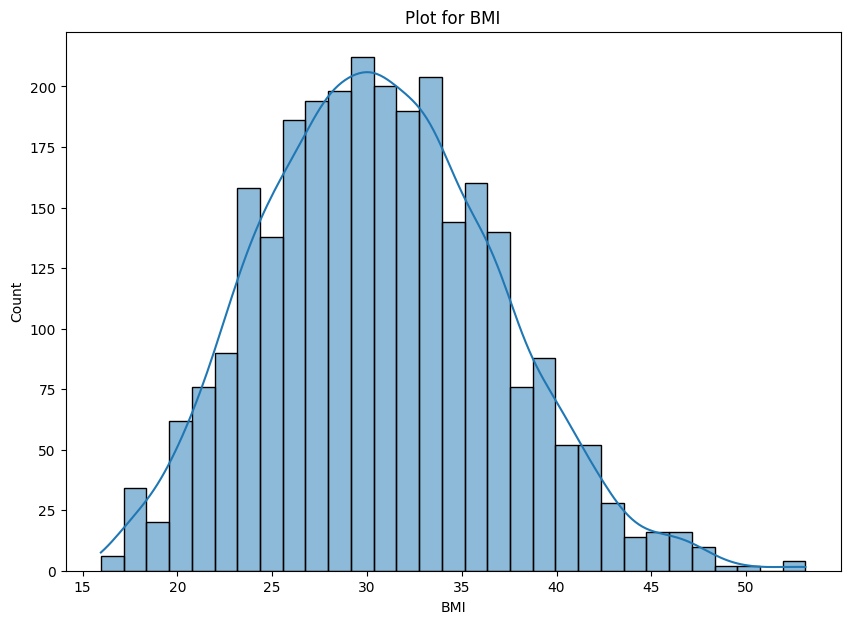

In [54]:
plt.figure(figsize = (10, 7))
sns.histplot(data_copy["bmi"], kde = True)
plt.title("Plot for BMI")
plt.xlabel("BMI")
plt.ylabel("Count");

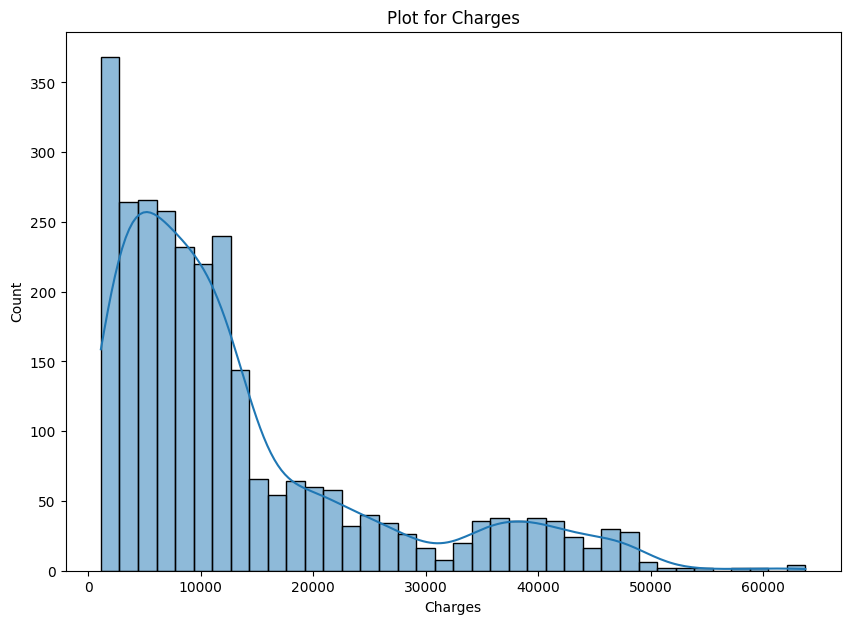

In [55]:
plt.figure(figsize = (10, 7))
sns.histplot(data_copy["charges"], kde = True)
plt.title("Plot for Charges")
plt.xlabel("Charges")
plt.ylabel("Count");

### There might be few outliers in Charges but then we cannot say that the value is an outlier as there might be cases in which charge for medical was very less actually!

## Preparing data - We can scale BMI and Charges columns before proceeding with prediction

In [56]:
data_copy.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,0,33.770,1,0,2,1725.55230
2,28,0,33.000,3,0,2,4449.46200
3,33,0,22.705,0,0,0,21984.47061
4,32,0,28.880,0,0,0,3866.85520


In [57]:
# Create a copy of the dataset
data_pre = data_copy.copy()

# Initialize the scaler
scaler = StandardScaler()

# Standardize multiple numerical columns at once
data_pre[['age', 'bmi', 'charges']] = scaler.fit_transform(
    data_pre[['age', 'bmi', 'charges']]
)

# Display the transformed dataset
data_pre.head()

,age,sex,bmi,children,smoker,region,charges
0,-1.428353,1,-0.457114,0,1,3,0.298245
1,-1.499381,0,0.500731,1,0,2,-0.949483
2,-0.789099,0,0.375085,3,0,2,-0.725285
3,-0.433959,0,-1.304814,0,0,0,0.717976
4,-0.504987,0,-0.297201,0,0,0,-0.773238


In [58]:
# Separate the features (X) and target variable (y)
X = data_pre.drop("charges", axis=1).values
y = data_pre["charges"].values.reshape(-1, 1)

# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create a StandardScaler for feature scaling
scaler = StandardScaler()

# Fit the scaler on the training features and transform them
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test features using the same scaler
X_test_scaled = scaler.transform(X_test)

# Scale the target values using the same scaler
y_train_scaled = scaler.fit_transform(y_train)
y_test_scaled = scaler.transform(y_test)

# Convert target arrays from 2D to 1D for compatibility with many ML models
y_train = y_train.ravel()
y_test = y_test.ravel()

# Display the dimensions of the training and testing datasets
print("Size of X_train  :", X_train.shape)
print("Size of y_train  :", y_train.shape)
print("Size of X_test   :", X_test.shape)
print("Size of y_test   :", y_test.shape)

Size of X_train  : (2217, 6)
Size of y_train  : (2217,)
Size of X_test   : (555, 6)
Size of y_test   : (555,)


---

# Random Forest Regression

In [59]:
# Create a Random Forest Regressor model
reg_rf = RandomForestRegressor()

# Define the hyperparameter grid for tuning
parameters = {
    'n_estimators': [600, 1200],
    'max_features': ['sqrt'],
    'max_depth': [50, 60],
    'min_samples_split': [5, 7],
    'min_samples_leaf': [6, 12],
    'criterion': ['squared_error']
}

# Perform Grid Search with 10-fold cross-validation
# to find the best combination of hyperparameters
reg_rf_gscv = GridSearchCV(
    estimator=reg_rf,
    param_grid=parameters,
    cv=10,
    n_jobs=-1
)

# Train the model using all parameter combinations
reg_rf_gscv = reg_rf_gscv.fit(X_train, y_train)

In [60]:
reg_rf_gscv.best_score_

np.float64(0.8785145099471128)

In [61]:
reg_rf_gscv.best_params_

{'criterion': 'squared_error',
 'max_depth': 60,
 'max_features': 'sqrt',
 'min_samples_leaf': 6,
 'min_samples_split': 7,
 'n_estimators': 1200}

In [62]:
# Create a Random Forest Regressor using the best hyperparameters
# obtained from GridSearchCV
rf_reg = RandomForestRegressor(
    max_depth=60,
    min_samples_split=5,
    min_samples_leaf=6,
    n_estimators=1200
)

# Train the Random Forest model on the training data
rf_reg.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",60
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",6
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numbe

In [63]:
# Retrieve the best cross-validation score from GridSearchCV
cv_rf = reg_rf_gscv.best_score_

# Generate predictions on the training set
y_pred_rf_train = rf_reg.predict(X_train)

# Calculate the R² score for the training set
r2_score_rf_train = r2_score(y_train, y_pred_rf_train)

# Generate predictions on the test set
y_pred_rf_test = rf_reg.predict(X_test)

# Calculate the R² score for the test set
r2_score_rf_test = r2_score(y_test, y_pred_rf_test)

# Compute the Root Mean Squared Error (RMSE) on the test set
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))

# Display the model's performance metrics
print("CV               : {0:.3f}".format(cv_rf))
print("R2 Score (train) : {0:.3f}".format(r2_score_rf_train))
print("R2 Score (test)  : {0:.3f}".format(r2_score_rf_test))
print("RMSE             : {0:.3f}".format(rmse_rf))

CV               : 0.879
R2 Score (train) : 0.927
R2 Score (test)  : 0.886
RMSE             : 0.344


---

# Linear Regression

In [64]:
# Create the Linear Regression model
linear_reg = LinearRegression()

# Train the model using the training data
linear_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.3 , 0.01, 0.16, 0.04, 1.96,-0.03]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.4119
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[57.08,54.31,47.98,42.85,23.6 ,18.98]"


In [65]:
# Perform 10-fold cross-validation
cv_linear_reg = cross_val_score(
    estimator = linear_reg,
    X = X,
    y = y,
    cv = 10
)

# Make prediction on the training set
y_pred_linear_reg_train = linear_reg.predict(X_train)
# Calculate the R2_score for the training set
r2_score_linear_reg_train = r2_score(y_train, y_pred_linear_reg_train)


# Make prediction on the testing set
y_pred_linear_reg_test = linear_reg.predict(X_test)
# Calculate the R2_score for the testing set
r2_score_linear_reg_test = r2_score(y_test, y_pred_linear_reg_test)


# Calculate the root mean squared error (RMSE)
rmse_linear = (np.sqrt(mean_squared_error(y_test, y_pred_linear_reg_test)))

# Display the Evaluation Results
print("CV Linear Regression  : {0:.3f}".format(cv_linear_reg.mean()))
print("R2_score (train)      : {0:.3f}".format(r2_score_linear_reg_train))
print("R2_score (test)       : {0:.3f}".format(r2_score_linear_reg_test))
print("RMSE                  : {0:.3f}".format(rmse_linear))

CV Linear Regression  : 0.748
R2_score (train)      : 0.753
R2_score (test)       : 0.740
RMSE                  : 0.520


## Support Victor Machine (Regression)

In [66]:
# Create the Support Victor Machine (SVM)
svr = SVR()

# svr.fit(X_train_scaled, y_train_scaled)

In [67]:
# Define the hyperparameter grid for tuning the Support Vector Regressor (SVR)
parameters = {
    'kernel': ['rbf', 'sigmoid'],
    'gamma': [0.001, 0.01, 0.1, 1, 'scale'],
    'tol': [0.0001],
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Perform Grid Search with 10-fold cross-validation
# to find the best combination of hyperparameters
svr_grid = GridSearchCV(
    estimator=svr,
    param_grid=parameters,
    cv=10,
    verbose=4,
    n_jobs=-1
)

# Train the GridSearchCV object on the scaled training data
svr_grid.fit(X_train_scaled, y_train)

Fitting 10 folds for each of 60 candidates, totalling 600 fits
[CV 4/10] END C=0.001, gamma=0.001, kernel=rbf, tol=0.0001;, score=-0.088 total time=   0.2s
[CV 1/10] END C=0.001, gamma=0.001, kernel=rbf, tol=0.0001;, score=-0.122 total time=   0.3s
[CV 3/10] END C=0.001, gamma=0.001, kernel=rbf, tol=0.0001;, score=-0.099 total time=   0.2s
[CV 2/10] END C=0.001, gamma=0.001, kernel=rbf, tol=0.0001;, score=-0.103 total time=   0.3s
[CV 6/10] END C=0.001, gamma=0.001, kernel=rbf, tol=0.0001;, score=-0.111 total time=   0.3s
[CV 8/10] END C=0.001, gamma=0.001, kernel=rbf, tol=0.0001;, score=-0.085 total time=   0.3s
[CV 7/10] END C=0.001, gamma=0.001, kernel=rbf, tol=0.0001;, score=-0.088 total time=   0.3s
[CV 9/10] END C=0.001, gamma=0.001, kernel=rbf, tol=0.0001;, score=-0.082 total time=   0.3s
[CV 10/10] END C=0.001, gamma=0.001, kernel=rbf, tol=0.0001;, score=-0.126 total time=   0.3s
[CV 5/10] END C=0.001, gamma=0.001, kernel=rbf, tol=0.0001;, score=-0.091 total time=   0.3s
[CV 2/

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'gamma': [0.001, 0.01, ...], 'kernel': ['rbf', 'sigmoid'], 'tol': [0.0001]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",4
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`

In [68]:
svr_grid.best_score_

np.float64(0.8766604779980642)

In [69]:
svr_grid.best_params_

{'C': 10, 'gamma': 1, 'kernel': 'rbf', 'tol': 0.0001}

In [70]:
# Create a Support Vector Regressor (SVR) using the best hyperparameters
svr = SVR(
    C=10,
    gamma=1,
    tol=0.0001
)

# Train the SVR model on the scaled training data
svr.fit(X_train_scaled, y_train)

,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [71]:
# Retrieve the best cross-validation score from GridSearchCV
cv_svr = svr_grid.best_score_

# Generate predictions on the training set
y_pred_svr_train = svr.predict(X_train_scaled)

# Calculate the R² score for the training set
r2_score_svr_train = r2_score(y_train, y_pred_svr_train)

# Generate predictions on the test set
y_pred_svr_test = svr.predict(X_test_scaled)

# Calculate the R² score for the test set
r2_score_svr_test = r2_score(y_test, y_pred_svr_test)

# Compute the Root Mean Squared Error (RMSE) on the test set
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr_test))

# Display the model's performance metrics
print("CV               : {0:.3f}".format(cv_svr))
print("R2 Score (train) : {0:.3f}".format(r2_score_svr_train))
print("R2 Score (test)  : {0:.3f}".format(r2_score_svr_test))
print("RMSE             : {0:.3f}".format(rmse_svr))

CV               : 0.877
R2 Score (train) : 0.952
R2 Score (test)  : 0.856
RMSE             : 0.387


# Ridge Regressor

In [72]:
# Define the preprocessing and modeling steps for the pipeline
steps = [
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('ridge', Ridge())
]

# Create a pipeline that sequentially applies preprocessing and modeling
ridge_pipe = Pipeline(steps)

In [73]:
# Define the hyperparameter grid for tuning the Ridge Regression model
parameters = {
    'ridge__alpha': [
        1e-15, 1e-10, 1e-8, 1e-3, 1e-2,
        1, 2, 5, 10, 20, 25, 35, 43, 55, 100
    ],
    'ridge__random_state': [42]
}

# Perform Grid Search with 10-fold cross-validation
# to find the best Ridge Regression hyperparameters
reg_ridge = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=parameters,
    cv=10
)

# Train the GridSearchCV object on the training data
reg_ridge.fit(X_train, y_train)

/home/karo_mamandi/User/Pycharm/.venv2/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.0862145686078286e-19.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/karo_mamandi/User/Pycharm/.venv2/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.0608444750256632e-19.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/karo_mamandi/User/Pycharm/.venv2/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.0461095870939868e-19.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...e', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ridge__alpha': [1e-15, 1e-10, ...], 'ridge__random_state': [42]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of i

In [74]:
reg_ridge.best_score_

np.float64(0.8411478791324823)

In [75]:
reg_ridge.best_params_

{'ridge__alpha': 20, 'ridge__random_state': 42}

In [76]:
# Create a Ridge Regression model using the best hyperparameters
ridge = Ridge(
    alpha=20,
    random_state=42
)

# Train the Ridge Regression model on the scaled training data
ridge.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",20
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary <random_state>` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",42
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"posi

In [77]:
# Retrieve the best cross-validation score from GridSearchCV
cv_ridge = reg_ridge.best_score_

# Generate predictions on the training set
y_pred_ridge_train = ridge.predict(X_train_scaled)

# Calculate the R² score for the training set
r2_score_ridge_train = r2_score(y_train, y_pred_ridge_train)

# Generate predictions on the test set
y_pred_ridge_test = ridge.predict(X_test_scaled)

# Calculate the R² score for the test set
r2_score_ridge_test = r2_score(y_test, y_pred_ridge_test)

# Compute the Root Mean Squared Error (RMSE) on the test set
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))

# Display the model's performance metrics
print("CV               : {0:.3f}".format(cv_ridge))
print("R2 Score (train) : {0:.3f}".format(r2_score_ridge_train))
print("R2 Score (test)  : {0:.3f}".format(r2_score_ridge_test))
print("RMSE             : {0:.3f}".format(rmse_ridge))

CV               : 0.841
R2 Score (train) : 0.753
R2 Score (test)  : 0.739
RMSE             : 0.520


---

In [88]:
# Store the evaluation metrics for each trained model
models = [
    ("Random Forest Regression", rmse_rf, r2_score_rf_train, r2_score_rf_test, cv_rf.mean()),
    ("Linear Regression", rmse_linear, r2_score_linear_reg_train, r2_score_linear_reg_test, cv_linear_reg.mean()),
    ("Support Vector Regression", rmse_svr, r2_score_svr_train, r2_score_svr_test, cv_svr.mean()),
    ("Ridge Regression", rmse_ridge, r2_score_ridge_train, r2_score_ridge_test, cv_ridge.mean())
]

In [91]:
# Create a DataFrame to compare the performance of all trained models
predict = pd.DataFrame(
    data=models,
    columns=[
        'Model',
        'RMSE',
        'R2_Score(train)',
        'R2_Score(test)',
        'Cross-Validation'
    ]
)

# Display the model comparison table
predict

,Model,RMSE,R2_Score(train),R2_Score(test),Cross-Validation
0,Random Forest Regression,0.344078,0.927159,0.886137,0.878515
1,Linear Regression,0.520119,0.752932,0.739820,0.748018
2,Support Vector Regression,0.387203,0.951972,0.855806,0.876660
3,Ridge Regression,0.520495,0.752870,0.739444,0.841148


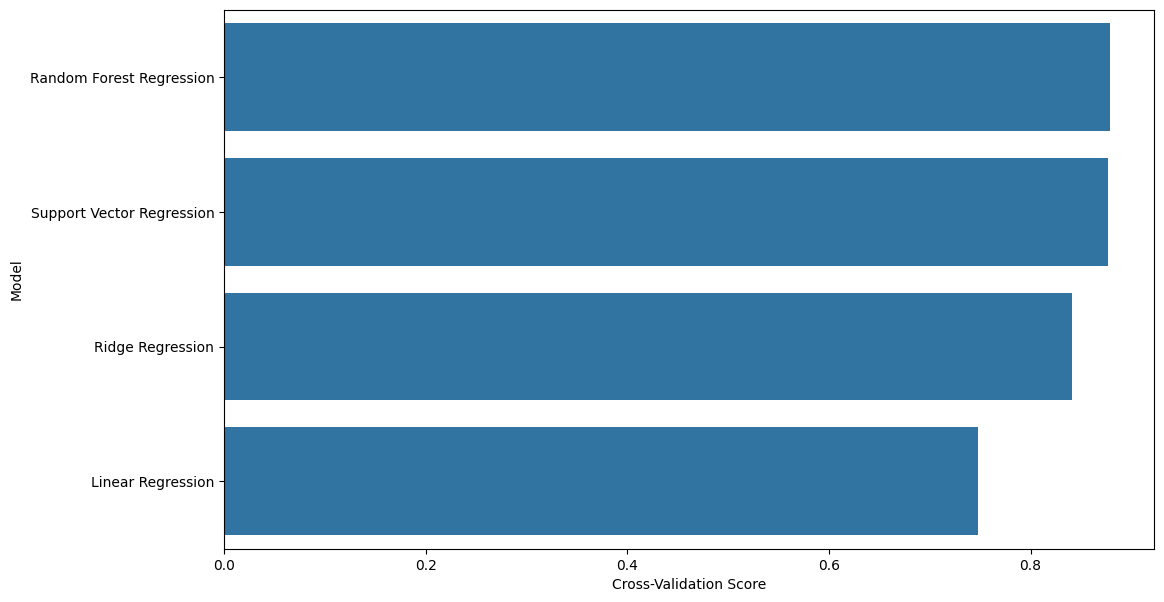

In [103]:
# Create a figure for the comparison chart
plt.figure(figsize=(12, 7))

# Sort the models by cross-validation score in descending order
predict.sort_values(by="Cross-Validation", ascending=False, inplace=True)

# Create a horizontal bar chart of model cross-validation scores
sns.barplot(
    data=predict,
    x="Cross-Validation",
    y="Model"
)

# Label the x-axis
plt.xlabel("Cross-Validation Score");

---

# Training Data without Scaling for Random Forest Regression

In [93]:
data_copy.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,0,33.770,1,0,2,1725.55230
2,28,0,33.000,3,0,2,4449.46200
3,33,0,22.705,0,0,0,21984.47061
4,32,0,28.880,0,0,0,3866.85520


In [94]:
# Separate the features (X) and target variable (y) from the encoded dataset
X_ = data_copy.drop('charges', axis=1).values
y_ = data_copy['charges'].values.reshape(-1, 1)

# Split the dataset into training and testing sets (80% training, 20% testing)
X_train_, X_test_, y_train_, y_test_ = train_test_split(
    X_,
    y_,
    test_size=0.2,
    random_state=42
)

# Convert the target arrays from 2D to 1D
# for compatibility with most scikit-learn models
y_train_ = y_train_.ravel()
y_test_ = y_test_.ravel()

# Display the dimensions of the training and testing datasets
print("Size of X_train_ :", X_train_.shape)
print("Size of y_train_ :", y_train_.shape)
print("Size of X_test_  :", X_test_.shape)
print("Size of y_test_  :", y_test_.shape)

Size of X_train_ : (2217, 6)
Size of y_train_ : (2217,)
Size of X_test_  : (555, 6)
Size of y_test_  : (555,)


In [95]:
# Create a Random Forest Regressor using the selected hyperparameters
rf_reg = RandomForestRegressor(
    max_depth=60,
    min_samples_split=5,
    min_samples_leaf=6,
    n_estimators=1200
)

# Train the Random Forest model on the training dataset
rf_reg.fit(X_train_, y_train_)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",60
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",6
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numbe

In [96]:
# Generate predictions on the training set
y_pred_rf_train = rf_reg.predict(X_train_)

# Calculate the R² score for the training set
r2_score_rf_train = r2_score(y_train_, y_pred_rf_train)

# Generate predictions on the test set
y_pred_rf_test = rf_reg.predict(X_test_)

# Calculate the R² score for the test set
r2_score_rf_test = r2_score(y_test_, y_pred_rf_test)

# Display the model's performance on the training and test sets
print("R2 Score (train) : {0:.3f}".format(r2_score_rf_train))
print("R2 Score (test)  : {0:.3f}".format(r2_score_rf_test))

R2 Score (train) : 0.927
R2 Score (test)  : 0.886


In [97]:
# Import the pickle module for model serialization
import pickle

# Specify the filename for the saved model
Pkl_Filename = "rf_tuned_model.pkl"

# Save the trained Random Forest model to a pickle file
with open(Pkl_Filename, "wb") as file:
    pickle.dump(rf_reg, file)

In [98]:
# Load the trained Random Forest model from the pickle file
with open(Pkl_Filename, "rb") as file:
    rf_tuned_loaded = pickle.load(file)

In [99]:
rf_tuned_loaded

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",60
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",6
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numbe

In [100]:
# Predict the insurance charge for a new customer
# Input format: [age, sex, bmi, children, smoker, region]
pred = rf_tuned_loaded.predict(
    np.array([20, 1, 28, 0, 1, 3]).reshape(1, 6)
)[0]

In [101]:
# Display the predicted insurance charge with three decimal places
print("{0:.3f}".format(pred))

18606.442


In [102]:
# Define sample customer profiles for prediction
# Feature order:
# [age, sex, bmi, children, smoker, region]
#
# Encoding:
# sex    -> male = 0, female = 1
# smoker -> no = 0, yes = 1
# region -> northwest = 0, northeast = 1,
#           southeast = 2, southwest = 3
examples = np.array([
    [25, 0, 22.5, 0, 0, 2],   # Young male, non-smoker
    [40, 1, 28.4, 2, 0, 1],   # Middle-aged female, non-smoker
    [30, 1, 31.2, 1, 1, 0],   # Young female, smoker
    [58, 0, 36.5, 3, 0, 3],   # Older male, obese, non-smoker
    [62, 1, 33.8, 2, 1, 2],   # Older female, smoker
    [19, 0, 20.8, 0, 0, 1],   # Young healthy male
    [45, 1, 26.7, 1, 0, 0],   # Middle-aged healthy female
    [35, 0, 29.9, 2, 1, 3],   # Male smoker
    [50, 1, 40.2, 4, 0, 2],   # Obese female with children
    [27, 1, 24.3, 0, 0, 1]    # Young healthy female
])

# If the model was trained on scaled features,
# scale the input data before making predictions
# examples = scaler.transform(examples)

# Predict insurance charges for all sample customers
predictions = rf_tuned_loaded.predict(examples)

# Display each customer's input features and predicted insurance charge
for person, pred in zip(examples, predictions):
    print(f"Input: {person.tolist()}")
    print(f"Predicted insurance charge: ${pred:,.2f}\n")

Input: [25.0, 0.0, 22.5, 0.0, 0.0, 2.0]
Predicted insurance charge: $4,162.34

Input: [40.0, 1.0, 28.4, 2.0, 0.0, 1.0]
Predicted insurance charge: $7,550.74

Input: [30.0, 1.0, 31.2, 1.0, 1.0, 0.0]
Predicted insurance charge: $37,415.30

Input: [58.0, 0.0, 36.5, 3.0, 0.0, 3.0]
Predicted insurance charge: $13,940.14

Input: [62.0, 1.0, 33.8, 2.0, 1.0, 2.0]
Predicted insurance charge: $47,988.38

Input: [19.0, 0.0, 20.8, 0.0, 0.0, 1.0]
Predicted insurance charge: $1,627.99

Input: [45.0, 1.0, 26.7, 1.0, 0.0, 0.0]
Predicted insurance charge: $9,270.43

Input: [35.0, 0.0, 29.9, 2.0, 1.0, 3.0]
Predicted insurance charge: $20,433.73

Input: [50.0, 1.0, 40.2, 4.0, 0.0, 2.0]
Predicted insurance charge: $11,158.37

Input: [27.0, 1.0, 24.3, 0.0, 0.0, 1.0]
Predicted insurance charge: $4,219.73

